# Lab01 -- Cotizaciones Optimas de un Formador de Mercado

Notebook generado automaticamente por `main.py` (no editado a mano). Reproduce las 5 figuras del proyecto junto con una breve interpretacion de cada una, condensada de las 5 preguntas de analisis de README.md. Seed=42 en toda la simulacion.

In [1]:
%matplotlib inline

from src.model import PI_I, PI_L, S0, analisis_sensibilidad, optimizar_cotizaciones
from src.simulation import construir_regimenes, simular_monte_carlo, simular_trades
from src.plots import (
    figura_histograma_monte_carlo,
    figura_inventario_acumulado,
    figura_pnl_acumulado,
    figura_probabilidad_ejecucion,
    figura_sensibilidad,
)

optimo = optimizar_cotizaciones(PI_I, PI_L, S0)
regimenes = construir_regimenes()
trades_por_regimen = {
    nombre: simular_trades(bid, ask, n_trades=10000, seed=42)
    for nombre, (bid, ask) in regimenes.items()
}
resumen_mc, pnl_finales = simular_monte_carlo(
    regimenes, n_corridas=1000, n_trades=1000, seed=42, devolver_pnl_finales=True
)
sensibilidad = analisis_sensibilidad()

print({clave: float(valor) for clave, valor in optimo.items()})


{'bid': 16.45, 'ask': 23.43, 'spread': 6.98, 'utilidad': 0.84}


**Probabilidad de ejecucion vs. spread.** Cae linealmente y llega a cero en s=6.25 (marcado en la grafica). Mas alla de ese punto, la simulacion solo sigue generando trades porque los fuerza via el desempate contra S0, no porque exista demanda real de un trader de liquidez -- ver la advertencia de interpretacion del proyecto.

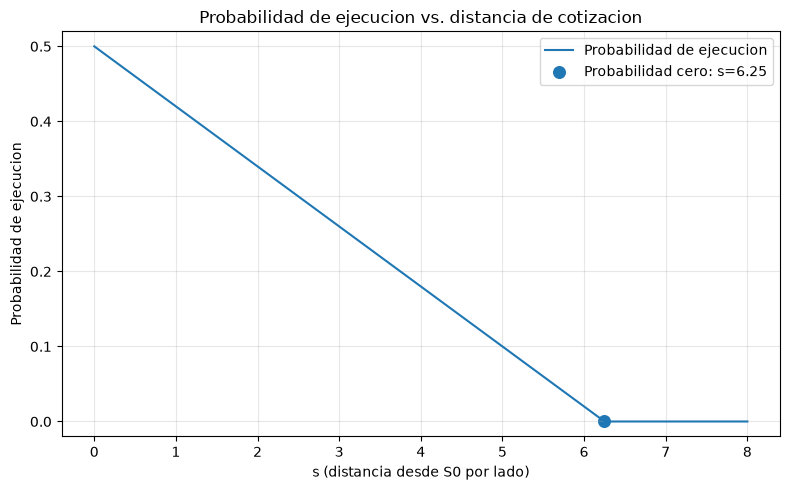

In [2]:
figura_probabilidad_ejecucion();

**P&L acumulado por regimen (Pregunta 1).** Con el regimen Estrecho (spread=0.30) el formador casi no cobra por proveer liquidez pero sigue expuesto por completo a los informados: el P&L acumulado de 10,000 trades termina en -6,873.10, mostrando por que un spread demasiado angosto no compensa la seleccion adversa.

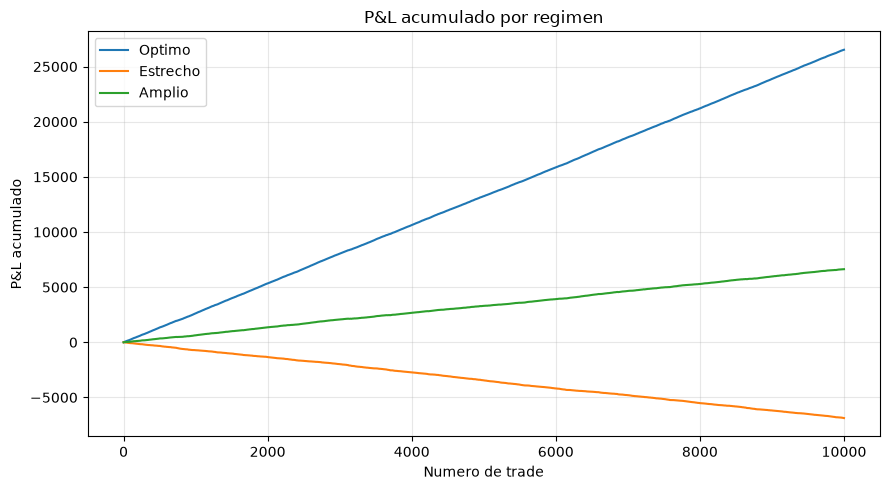

In [3]:
figura_pnl_acumulado(trades_por_regimen);

**Inventario acumulado por regimen (Pregunta 3).** El inventario final tras 10,000 trades es +34 (Optimo), -38 (Estrecho) y -38 (Amplio). La componente de informados es identica en los tres regimenes (-28); la diferencia viene del sorteo de liquidez, 50/50 en Estrecho y Amplio (simetricos alrededor de S0) y sesgado en Optimo (ligeramente asimetrico).

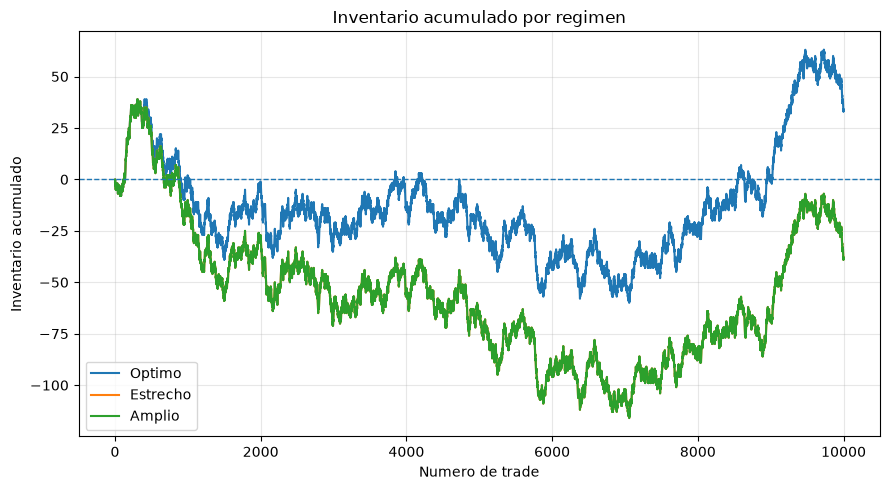

In [4]:
figura_inventario_acumulado(trades_por_regimen);

**Distribucion del P&L final -- Monte Carlo (Preguntas 1 y 2).** Estrecho pierde en el 100% de las 1,000 corridas (prob_perdida=1.0). Ademas, el PnL medido del lado informado se infla artificialmente en spreads anchos: en Amplio, el promedio "con todo" es -0.58 pero cae a -1.65 filtrando solo a trades con ventaja genuina -- 44.2% de los "informados" en ese regimen fueron forzados sin ventaja real.

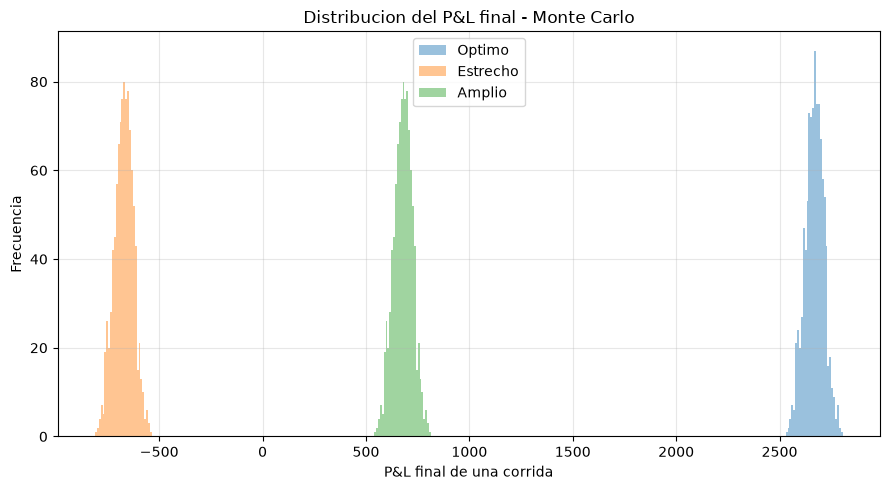

In [5]:
figura_histograma_monte_carlo(pnl_finales);

**Spread optimo vs. pi_I (Pregunta 4).** Crece monotonamente: 6.40 (pi_I=0.1) -> 6.98 (pi_I=0.4) -> 7.99 (pi_I=0.7), consistente con la teoria de seleccion adversa -- a mayor proporcion de informados, mayor el spread que compensa el riesgo.

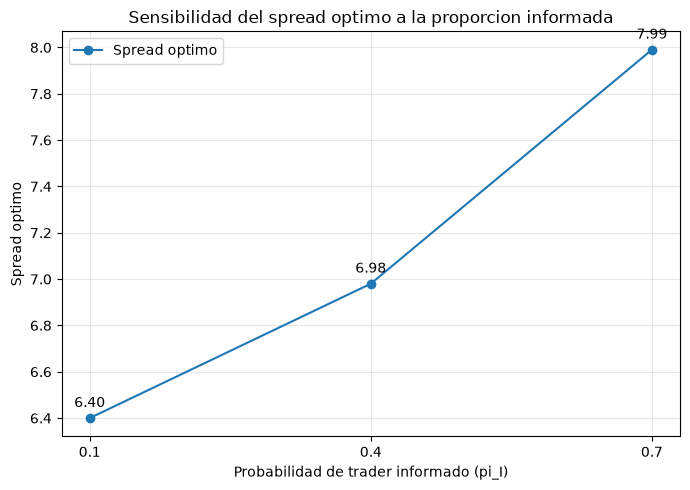

In [6]:
figura_sensibilidad(sensibilidad);